# **05 - K-Means clustering: cluster-median predictor and feature generator**

K-Means is unsupervised, so it is not a predictor by itself. It is evaluated in two ways, per track, on TEST (2025):

1. **`kmeans_median`**: each row is assigned to a TRAIN cluster and receives the TRAIN median target of that cluster.
2. **Feature generator**: the cluster label is added as a categorical feature to the best linear and boosting configurations with a time feature (`ridge_time_kmeans`, `hgb_time_kmeans`). Their hyperparameters are those of `ridge_time` and `hgb_time` loaded from `reports/metrics`, so the difference to those models isolates the effect of the cluster label.

**Leakage rules.** The scaler, the one-hot encoder and K-Means are fit on TRAIN only, and TEST rows only receive labels through `predict`. The clustering never uses the target. The descriptors are structural: `log_area`, `floor` (median-imputed) with `floor_missing`, `building_age` and `building_type`. District identity is not a descriptor (it is already a feature of the supervised models), and no target-based district statistic is used.

**Choice of k (TRAIN only, k = 2..12).** For each k, K-Means is fit with 10 seeds. Evidence: inertia (elbow), mean silhouette on a fixed TRAIN subsample of 6,000 rows, and stability (mean pairwise adjusted Rand index between the labelings of the 10 seeds). Rule fixed before looking at the results: choose the k with the highest mean silhouette among the k that are stable (mean ARI of at least 0.80) and have k >= 4, because fewer than four clusters cannot represent the four building types.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from rent_model import config
from rent_model.clustering import (BoostedWithClusters, ClusterMedian, StructuralKMeans,
                                   build_ridge_kmeans_pipeline, describe_clusters, name_clusters, select_k)
from rent_model.data import load_clean
from rent_model.features import build_features, build_target, inverse_target, select_track
from rent_model.io import save_run
from rent_model.metrics import all_metrics, paired_bootstrap_wape_diff
from rent_model.splits import temporal_split

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 170)
plt.rcParams['figure.dpi'] = 100
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Data and reference models

In [2]:
df = load_clean()
data = {}
for track, spec in config.TRACKS.items():
    train, test = temporal_split(select_track(df, track))
    data[track] = dict(train=train, test=test, target=spec['target'],
                       X_train=build_features(train, track, include_time=True), y_train_log=build_target(train, track),
                       X_test=build_features(test, track, include_time=True), y_test=test[spec['target']])
    print(f"{track}: train {len(train):,} rows, test {len(test):,} rows")

def last_run(track, model_id):
    return json.loads((config.METRICS_DIR / f'{track}__{model_id}.json').read_text(encoding='utf-8'))[-1]

REFERENCES = ['baseline_district_type', 'ridge_time', 'hgb_time']
params = {track: {'ridge_alpha': last_run(track, 'ridge_time')['meta']['params']['alpha'],
                  'hgb': last_run(track, 'hgb_time')['meta']['params']} for track in config.TRACKS}
for track in config.TRACKS:
    print(track, '-> ridge_time alpha:', params[track]['ridge_alpha'], '| hgb_time params:', params[track]['hgb'])

jeonse: train 138,848 rows, test 37,935 rows
wolse: train 152,714 rows, test 57,829 rows
jeonse -> ridge_time alpha: 0.01 | hgb_time params: {'learning_rate': 0.03, 'max_iter': 600, 'max_leaf_nodes': 127, 'min_samples_leaf': 20, 'l2_regularization': 0.0}
wolse -> ridge_time alpha: 0.01 | hgb_time params: {'learning_rate': 0.05, 'max_iter': 600, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 10.0}


## Choice of k (TRAIN only)

In [3]:
selection, chosen_k = {}, {}
for track in config.TRACKS:
    chosen_k[track], selection[track] = select_k(data[track]['X_train'])
    print(f'{track}: chosen k = {chosen_k[track]}')
    display(selection[track])

jeonse: chosen k = 4


,inertia,silhouette,silhouette_std,stability_ari,stability_ari_min,inertia_drop_pct,eligible
k,,,,,,,
2,"473,848.6581",0.3203,0.0660,0.5798,0.1040,NaN,False
3,"338,320.8927",0.3317,0.0457,0.7631,0.3441,28.6015,False
4,"247,017.2691",0.3502,0.0002,0.9940,0.9897,26.9873,True
5,"218,562.3961",0.3194,0.0045,0.7034,0.5063,11.5194,False
6,"194,323.0145",0.3256,0.0064,0.6900,0.4549,11.0904,False
7,"168,726.3269",0.3389,0.0101,0.7645,0.5731,13.1722,False
8,"151,102.5844",0.3441,0.0106,0.7681,0.5957,10.4452,False
9,"138,138.5883",0.3377,0.0143,0.7859,0.5770,8.5796,False
10,"127,281.4182",0.3352,0.0111,0.8221,0.6443,7.8596,True


wolse: chosen k = 4


,inertia,silhouette,silhouette_std,stability_ari,stability_ari_min,inertia_drop_pct,eligible
k,,,,,,,
2,"491,742.9172",0.3462,0.0000,1.0000,1.0000,NaN,False
3,"374,239.6642",0.3532,0.0001,0.9917,0.9838,23.8953,False
4,"303,581.0540",0.3493,0.0115,0.8411,0.5595,18.8806,True
5,"258,197.8615",0.3465,0.0081,0.7952,0.5614,14.9493,False
6,"228,114.1849",0.3357,0.0052,0.8391,0.3983,11.6514,True
7,"206,850.9690",0.3243,0.0111,0.7202,0.4122,9.3213,False
8,"186,123.3457",0.3270,0.0152,0.7409,0.5270,10.0206,False
9,"170,909.8990",0.3190,0.0201,0.7202,0.5232,8.1739,False
10,"158,489.0400",0.3249,0.0150,0.7628,0.5715,7.2675,False


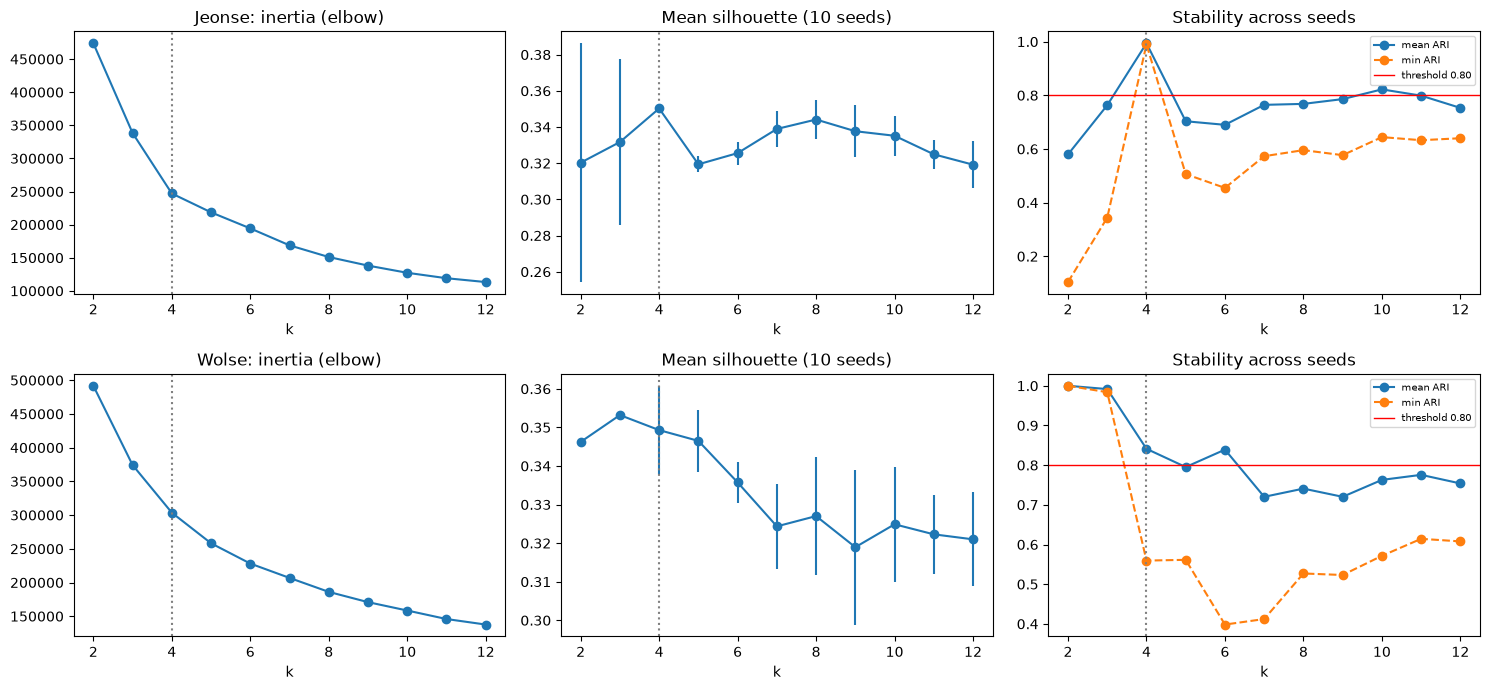

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for r, track in enumerate(config.TRACKS):
    t = selection[track]; k = chosen_k[track]
    axes[r, 0].plot(t.index, t['inertia'], marker='o'); axes[r, 0].set_title(f'{track.capitalize()}: inertia (elbow)')
    axes[r, 1].errorbar(t.index, t['silhouette'], yerr=t['silhouette_std'], marker='o'); axes[r, 1].set_title('Mean silhouette (10 seeds)')
    axes[r, 2].plot(t.index, t['stability_ari'], marker='o', label='mean ARI')
    axes[r, 2].plot(t.index, t['stability_ari_min'], marker='o', ls='--', label='min ARI')
    axes[r, 2].axhline(0.80, color='red', lw=1, label='threshold 0.80'); axes[r, 2].set_title('Stability across seeds'); axes[r, 2].legend(fontsize=7)
    for ax in axes[r]:
        ax.axvline(k, color='gray', ls=':'); ax.set_xlabel('k')
plt.tight_layout(); plt.show()

**Interpretation.** The rule selects k = 4 in both tracks. In Jeonse k = 4 is the clear choice: it has the highest silhouette among the eligible values (0.3502 against 0.3352 for k = 10, the only other eligible value), the most stable labeling of all k >= 4 (mean ARI 0.9940, minimum 0.9897) and the last large inertia drop (26.9873% from k = 3, against 11.5194% from k = 4 to k = 5), which is the elbow. In Wolse k = 4 is eligible with a mean ARI of 0.8411 (minimum 0.5595) and a silhouette of 0.3493, higher than k = 6 (0.3357), the other eligible value; the inertia decreases gradually (18.8806%, 14.9493%, 11.6514% for k = 4, 5, 6), so there is no sharp elbow. In Wolse the silhouette is almost flat from k = 2 to k = 5 (0.3462, 0.3532, 0.3493 and 0.3465), so it does not discriminate strongly among small k and the k >= 4 rule decides. The selection used TRAIN rows only.

## Cluster profiles (TRAIN) and 2D PCA

In [5]:
clusterers, profiles, names = {}, {}, {}
for track in config.TRACKS:
    d = data[track]
    clusterers[track] = StructuralKMeans(k=chosen_k[track]).fit(d['X_train'])
    profile = describe_clusters(d['X_train'], clusterers[track].labels_, d['train'][d['target']])
    names[track] = name_clusters(profile)
    test_labels = clusterers[track].predict(d['X_test'])
    profile['n_test'] = pd.Series(test_labels).value_counts().reindex(profile.index).fillna(0).astype(int)
    profile['median_target_test'] = d['y_test'].groupby(test_labels).median()
    profiles[track] = profile
    print(f'{track}: k = {chosen_k[track]}  (median_target is the target in 10,000 KRW, shown for description only)')
    display(profile.rename(index=names[track]).drop(columns=['n']).round(2))

jeonse: k = 4  (median_target is the target in 10,000 KRW, shown for description only)


,median_area_sqm,median_floor,median_building_age,share_pct,pct_Apartment,pct_Detached / Multi-household house,pct_Officetel,pct_Row house / Villa (multi-unit),median_target,n_test,median_target_test
cluster,,,,,,,,,,,
"C0 Detached house, small, older",36.0000,NaN,28.0000,13.6200,0.0000,100.0000,0.0000,0.0000,"12,000.0000",3977,"13,000.0000"
"C1 Apartment, large, older",64.6700,4.0000,25.0000,37.6400,76.3300,0.0000,1.1500,22.5200,"38,000.0000",15836,"43,000.0000"
"C2 Apartment, large, newer",84.4100,14.0000,15.0000,20.4500,97.0100,0.0000,2.9700,0.0200,"55,000.0000",9440,"60,900.0000"
"C3 Row house/Villa, small, newer",29.0700,4.0000,6.0000,28.2900,9.2400,0.0000,30.7400,60.0200,"22,000.0000",8682,"23,000.0000"


wolse: k = 4  (median_target is the target in 10,000 KRW, shown for description only)


,median_area_sqm,median_floor,median_building_age,share_pct,pct_Apartment,pct_Detached / Multi-household house,pct_Officetel,pct_Row house / Villa (multi-unit),median_target,n_test,median_target_test
cluster,,,,,,,,,,,
"C0 Apartment, large, older",59.8700,4.0000,22.0000,24.1400,65.9600,0.6000,2.0800,31.3600,65.0000,13489,70.0000
"C1 Row house/Villa, small, newer",24.0200,5.0000,7.0000,30.7100,17.3600,0.0000,40.7700,41.8700,53.0000,19357,55.0000
"C2 Apartment, large, newer",59.9200,15.0000,10.0000,13.3200,87.8600,0.0000,11.8800,0.2500,84.0000,7524,92.5000
"C3 Detached house, small, older",30.0000,NaN,28.0000,31.8300,0.0000,100.0000,0.0000,0.0000,45.0000,17459,50.0000


**Interpretation.** The four clusters are the same kind of groups in both tracks: small older detached houses (100.0000% Detached / Multi-household house, median age 28.0000 years in both tracks, share 13.6200% in Jeonse and 31.8300% in Wolse), small newer row houses / villas / officetels (shares 28.2900% and 30.7100%), and two groups of larger apartments split by age and floor (Jeonse: median floor 4.0000 and age 25.0000 against floor 14.0000 and age 15.0000; Wolse: floor 4.0000 and age 22.0000 against floor 15.0000 and age 10.0000). Names are assigned from the printed medians and the dominant building type: the cluster named after a type is not pure (for example 76.3300% of `C1` in Jeonse is Apartment and 22.5200% Row house / Villa). The clusters separate price levels: the TRAIN median target ranges from 12,000 to 55,000 in Jeonse and from 45.0000 to 84.0000 in Wolse, and the median in 2025 is higher than in TRAIN in every cluster (for example Jeonse `C2` 55,000 against 60,900, Wolse `C2` 84.0000 against 92.5000), so the 2025 shift is present inside every cluster.

jeonse: PCA explained variance ratio of PC1, PC2 = [0.3501, 0.2911] (total 0.6413)
wolse: PCA explained variance ratio of PC1, PC2 = [0.3616, 0.2767] (total 0.6383)


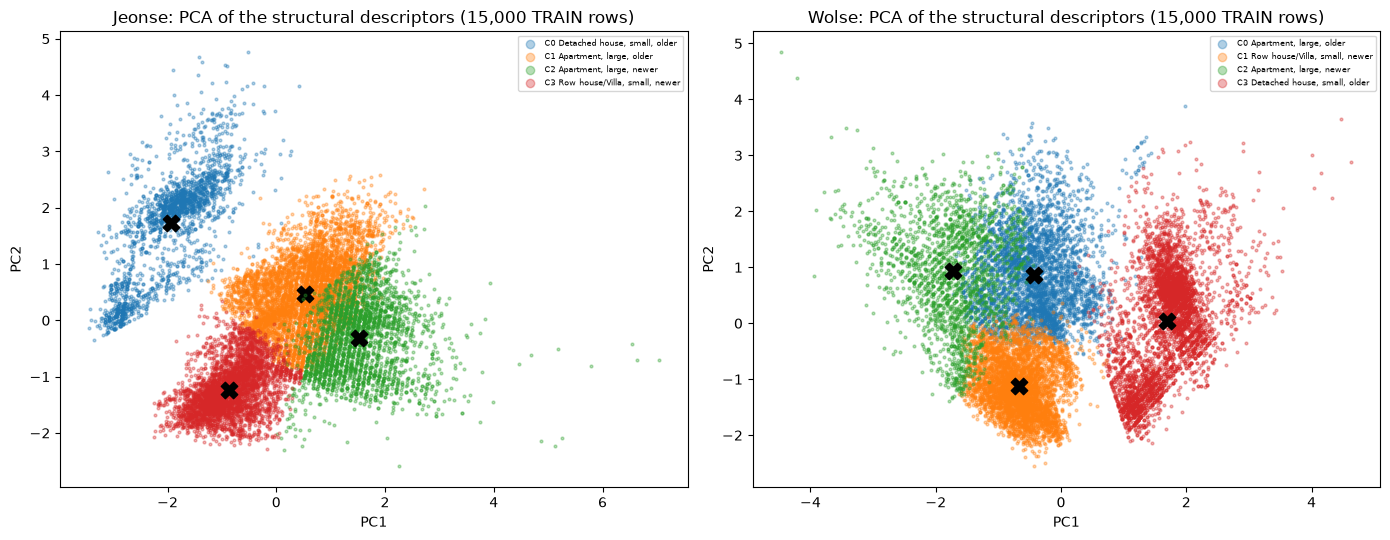

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
rng = np.random.default_rng(config.RANDOM_SEED)
for ax, track in zip(axes, config.TRACKS):
    d = data[track]; cl = clusterers[track]
    embed = cl.embed(d['X_train'])
    pca = PCA(n_components=2, random_state=config.RANDOM_SEED).fit(embed)
    idx = rng.choice(len(embed), size=15_000, replace=False)
    pts = pca.transform(embed[idx]); centers = pca.transform(cl.kmeans_.cluster_centers_)
    for c in range(cl.k):
        m = cl.labels_[idx] == c
        ax.scatter(pts[m, 0], pts[m, 1], s=4, alpha=0.35, label=names[track][c])
        ax.scatter(*centers[c], marker='X', s=140, color='black')
    ax.set_title(f'{track.capitalize()}: PCA of the structural descriptors (15,000 TRAIN rows)')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=6, markerscale=3)
    print(f"{track}: PCA explained variance ratio of PC1, PC2 = {np.round(pca.explained_variance_ratio_, 4).tolist()} "
          f"(total {pca.explained_variance_ratio_.sum():.4f})")
plt.tight_layout(); plt.show()

**Interpretation.** The first two principal components explain 0.6413 (Jeonse) and 0.6383 (Wolse) of the variance of the standardized descriptors, so the 2D plot is a partial view of the structure and overlaps in the plot do not imply overlaps in the full space.

## Models: cluster median and cluster label as a feature

In [7]:
fitted, preds, rows = {}, {}, []
for track in config.TRACKS:
    d = data[track]; k = chosen_k[track]; y_true = d['y_test'].to_numpy()
    models = {
        'kmeans_median': ClusterMedian(k=k),
        'ridge_time_kmeans': build_ridge_kmeans_pipeline(k, params[track]['ridge_alpha']),
        'hgb_time_kmeans': BoostedWithClusters(k=k, **params[track]['hgb']),
    }
    for model_id, model in models.items():
        if model_id == 'kmeans_median':
            model.fit(d['X_train'], d['train'][d['target']].to_numpy())
            pred = model.predict(d['X_test'])
        else:
            model.fit(d['X_train'], d['y_train_log'])
            pred = np.expm1(np.maximum(model.predict(d['X_test']), 0.0))
        fitted[(track, model_id)], preds[(track, model_id)] = model, pred
        rows.append({'track': track, 'model_id': model_id, **all_metrics(y_true, pred)})
metrics = pd.DataFrame(rows)

cols = ['n', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']
for track in config.TRACKS:
    table = metrics[metrics['track'] == track].set_index('model_id')[cols]
    for ref_id in REFERENCES:
        run = last_run(track, ref_id)
        table.loc[f'(ref) {ref_id}'] = [run[c] for c in cols]
    print(f'TEST metrics - {track} (k = {chosen_k[track]})')
    display(table)

TEST metrics - jeonse (k = 4)


,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
kmeans_median,"37,935.0000",41.7619,"18,822.4358",32.9268,-8.3333,-20.4745,0.5750,0.4207
ridge_time_kmeans,"37,935.0000",23.9687,"10,802.8903",18.2289,-8.1279,-11.7438,0.3502,0.7851
hgb_time_kmeans,"37,935.0000",17.3424,"7,816.3551",12.9657,-3.8072,-4.0169,0.2822,0.8604
(ref) baseline_district_type,"37,935.0000",34.4687,"15,535.3072",26.3158,-6.3830,-14.4528,0.4860,0.5860
(ref) ridge_time,"37,935.0000",24.0436,"10,836.6378",18.2974,-8.3812,-11.9167,0.3520,0.7829
(ref) hgb_time,"37,935.0000",17.3111,"7,802.2305",13.0657,-3.9480,-4.0113,0.2817,0.8609


TEST metrics - wolse (k = 4)


,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
kmeans_median,"57,829.0000",54.4581,40.8242,37.6471,-7.1429,-23.4074,0.8356,0.0522
ridge_time_kmeans,"57,829.0000",50.9666,38.2068,40.5855,-22.4960,-30.7961,0.7471,0.2424
hgb_time_kmeans,"57,829.0000",45.7855,34.3228,37.4642,-18.3461,-22.5682,0.6973,0.3400
(ref) baseline_district_type,"57,829.0000",51.9313,38.9300,35.5932,-6.2500,-19.5340,0.8137,0.1013
(ref) ridge_time,"57,829.0000",51.3471,38.4920,40.8782,-22.7534,-30.8606,0.7497,0.2372
(ref) hgb_time,"57,829.0000",45.7417,34.2900,37.3742,-18.2042,-22.4644,0.6973,0.3400


**Interpretation (Jeonse).** `kmeans_median` has a TEST WAPE of 41.7619%, worse than `baseline_district_type` (34.4687%) and with an aggregate bias of -20.4745%: four structural groups, without the district, explain less than district x type. As a feature, the cluster label leaves the supervised models unchanged: `ridge_time_kmeans` 23.9687% against 24.0436% for `ridge_time`, and `hgb_time_kmeans` 17.3424% against 17.3111% for `hgb_time`; their median biases are -8.1279% and -3.8072%, against -8.3812% and -3.9480%.

**Interpretation (Wolse).** `kmeans_median` has a WAPE of 54.4581%, against 51.9313% for `baseline_district_type` and 45.7417% for `hgb_time`. `ridge_time_kmeans` reaches 50.9666% against 51.3471% for `ridge_time`, and `hgb_time_kmeans` 45.7855% against 45.7417% for `hgb_time`. The biases remain close to those of the reference models (median bias -22.4960% against -22.7534% for ridge, -18.3461% against -18.2042% for HGB).

## Does the cluster label add predictive value? Paired deltas on TEST

In [8]:
comparisons = [('kmeans_median', 'baseline_district_type'), ('ridge_time_kmeans', 'ridge_time'),
               ('hgb_time_kmeans', 'hgb_time')]
delta_rows = []
for track in config.TRACKS:
    y_true = data[track]['y_test'].to_numpy()
    for new_id, ref_id in comparisons:
        ref = pd.read_parquet(config.PREDICTIONS_DIR / f'{track}__{ref_id}.parquet')
        assert np.allclose(ref['y_true'].to_numpy(), y_true), 'reference predictions are not in the same TEST order'
        boot = paired_bootstrap_wape_diff(y_true, preds[(track, new_id)], ref['y_pred'].to_numpy())
        delta_rows.append({'track': track, 'model': new_id, 'reference': ref_id,
                           'wape_new': all_metrics(y_true, preds[(track, new_id)])['wape_pct'],
                           'wape_ref': float(last_run(track, ref_id)['wape_pct']),
                           'delta_wape_pts': boot['diff'], 'ci95_low': boot['ci_low'], 'ci95_high': boot['ci_high'],
                           'prob_new_better': boot['prob_a_better']})
deltas = pd.DataFrame(delta_rows).set_index(['track', 'model', 'reference'])
display(deltas)

wape_new  wape_ref  delta_wape_pts  ci95_low  ci95_high  prob_new_better
track  model             reference                                                                                       
jeonse kmeans_median     baseline_district_type   41.7619   34.4687          7.2933    7.0405     7.5645           0.0000
       ridge_time_kmeans ridge_time               23.9687   24.0436         -0.0749   -0.1220    -0.0280           1.0000
       hgb_time_kmeans   hgb_time                 17.3424   17.3111          0.0313   -0.0040     0.0690           0.0490
wolse  kmeans_median     baseline_district_type   54.4581   51.9313          2.5268    2.3210     2.7153           0.0000
       ridge_time_kmeans ridge_time               50.9666   51.3471         -0.3804   -0.4223    -0.3379           1.0000
       hgb_time_kmeans   hgb_time                 45.7855   45.7417          0.0438    0.0004     0.0852           0.0230

**Interpretation.** The cluster label adds almost no predictive value. As a predictor, `kmeans_median` is worse than `baseline_district_type` by +7.2933 WAPE points in Jeonse (95% interval 7.0405 to 7.5645) and by +2.5268 in Wolse (2.3210 to 2.7153). As a feature for ridge, the change is small but its interval excludes zero: -0.0749 points in Jeonse (-0.1220 to -0.0280) and -0.3804 in Wolse (-0.4223 to -0.3379). For boosting the change is not an improvement: +0.0313 in Jeonse (-0.0040 to 0.0690, the interval includes zero) and +0.0438 in Wolse (0.0004 to 0.0852, slightly worse). A plausible reason, not tested here, is that the clusters give a linear model some non-additive combinations of area, floor, age and type, while the booster can learn those interactions from the original features. The gains of ridge are far smaller than the gap between ridge and boosting (23.9687% and 17.3424% in Jeonse).

## Save runs

In [9]:
for track in config.TRACKS:
    d = data[track]; k = chosen_k[track]
    sel = selection[track].loc[k]
    for model_id in ['kmeans_median', 'ridge_time_kmeans', 'hgb_time_kmeans']:
        meta = {'k': int(k), 'k_selection': {'silhouette': float(sel['silhouette']), 'stability_ari': float(sel['stability_ari']),
                                             'inertia': float(sel['inertia']), 'rule': 'max silhouette among stable (ARI >= 0.80) k >= 4'},
                'cluster_names': {int(c): n for c, n in names[track].items()},
                'descriptors': ['log_area', 'floor', 'floor_missing', 'building_age', 'building_type'],
                'fit_period': '2022-01-01..2024-12-31', 'eval_period': '2025'}
        if model_id == 'ridge_time_kmeans':
            meta.update(base_model='ridge_time', alpha=params[track]['ridge_alpha'])
        if model_id == 'hgb_time_kmeans':
            meta.update(base_model='hgb_time', params=params[track]['hgb'],
                        iterations_after_early_stopping=int(fitted[(track, model_id)].n_iter_))
        save_run(track, model_id, d['y_test'], preds[(track, model_id)], meta=meta,
                 context=d['test'][['district_name', 'contract_date']])
print('Saved', 3 * len(config.TRACKS), 'runs')

Saved 6 runs


## Summary

In [10]:
summary = metrics.pivot(index='model_id', columns='track', values=['wape_pct', 'median_bias_pct', 'aggregate_bias_pct'])
display(summary)

wape_pct         median_bias_pct          aggregate_bias_pct         
track               jeonse   wolse          jeonse    wolse             jeonse    wolse
model_id                                                                               
hgb_time_kmeans    17.3424 45.7855         -3.8072 -18.3461            -4.0169 -22.5682
kmeans_median      41.7619 54.4581         -8.3333  -7.1429           -20.4745 -23.4074
ridge_time_kmeans  23.9687 50.9666         -8.1279 -22.4960           -11.7438 -30.7961

## Conclusion

- **Chosen k.** k = 4 in both tracks, selected with TRAIN only: highest silhouette among the stable values with k >= 4 (mean ARI 0.9940 in Jeonse and 0.8411 in Wolse).
- **Clusters as a predictor.** `kmeans_median` (41.7619% in Jeonse, 54.4581% in Wolse) does not beat the district x type baseline (34.4687% and 51.9313%): structure without location is not enough.
- **Clusters as a feature.** The improvement is -0.0749 (Jeonse) and -0.3804 (Wolse) WAPE points for ridge, and no improvement for HGB (+0.0313 and +0.0438). The clusters are useful to describe the market segments (profile table) but not to improve the best models.